In [1]:
import sys
import os
import torch
import torchvision
import matplotlib.pyplot as plt

In [2]:
sys.path.append(os.path.abspath(os.path.join('..')))
%load_ext autoreload
%autoreload 2

In [3]:
from src.download_data import download_politicians
from src.data_filters import clean_dataset, split_train_val
from src.dataset import predprocessing_data
from src.model_builder import initialize_model
from src.train import train_model
from src.visualization import imshow, visualize_model, visualize_model_predictions
from src.compression import (build_quantizable_model, load_trained_weights,
                              to_fp16, static_quantize,
                              prepare_qat_model, convert_qat_model)
from src.benchmark import benchmark_all, evaluate_accuracy
from src.plots import (plot_size_vs_method, plot_latency_vs_method,
                        plot_accuracy_vs_method, plot_learning_curve)

In [4]:
politicians = ['Narendra Modi', 'Xi Jinping', 'Donald Trump', 'Sanae Takaichi',
               'Vladimir Putin', 'Javier Milei', 'Lee Jae-myung', 'Claudia Sheinbaum',
               'Mark Carney', 'Mohammed bin Salman']

## 1. Сбор и очистка датасета

In [5]:
download_politicians(politicians, samples_per_person=150)

2026-07-10 15:27:50,156 - INFO - icrawler.crawler - start crawling...
2026-07-10 15:27:50,157 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-07-10 15:27:50,157 - INFO - feeder - thread feeder-001 exit
2026-07-10 15:27:50,157 - INFO - icrawler.crawler - starting 1 parser threads...
2026-07-10 15:27:50,159 - INFO - icrawler.crawler - starting 1 downloader threads...


Uploading images for Narendra Modi


2026-07-10 15:27:50,786 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Narendra Modi official portrait&first=0
2026-07-10 15:27:52,924 - INFO - downloader - image #1	https://www.pmindia.gov.in/wp-content/uploads/2025/12/02.jpg
2026-07-10 15:27:53,330 - ERROR - downloader - Response status code 400, file https://upload.wikimedia.org/wikipedia/commons/thumb/b/be/Official_portrait_of_the_Prime_Minister_Narendra_Modi%2C_November_2020_(cropped).jpg
2026-07-10 15:27:53,929 - INFO - downloader - image #2	https://data1.ibtimes.co.in/en/full/781152/prime-minister-narendra-modi.jpg
2026-07-10 15:27:54,264 - INFO - downloader - image #3	https://www.shutterstock.com/shutterstock/photos/2238680849/display_1500/stock-photo-new-delhi-india-dec-indian-prime-minister-narendra-modi-seen-as-indian-national-flag-2238680849.jpg
2026-07-10 15:27:54,910 - INFO - downloader - image #4	https://img.freepik.com/premium-photo/perfect-portrait-pm-narendra-modi_1047923-2847.jpg
2026-07-10

Uploading images for Xi Jinping


2026-07-10 15:31:03,919 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Xi Jinping official portrait&first=0
2026-07-10 15:31:07,081 - INFO - downloader - image #1	http://images.china.cn/attachement/jpg/site1007/20121115/0019b91ec845120f25b702.jpg
2026-07-10 15:31:07,518 - ERROR - downloader - Response status code 400, file https://upload.wikimedia.org/wikipedia/commons/thumb/c/c9/Xi_Jinping_in_2025.jpg
2026-07-10 15:31:07,664 - INFO - downloader - image #2	https://upload.wikimedia.org/wikipedia/commons/0/04/Xi_Jinping_%28November_2024%29_02.jpg
2026-07-10 15:31:07,911 - INFO - downloader - image #3	https://imgcdn.stablediffusionweb.com/2024/5/9/b41363fd-71f5-405b-a328-be6aec7a1a71.jpg
2026-07-10 15:31:08,378 - INFO - downloader - image #4	https://chineseposters.net/sites/default/files/images/pc-2014-001.jpg
2026-07-10 15:31:09,297 - INFO - downloader - image #5	https://c8.alamy.com/comp/2Y72C8M/xi-jinping-portrait-of-the-president-of-china-xi-jinping-b1953-in

...

Uploading images for Mark Carney


2026-07-10 15:49:28,259 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Mark Carney official portrait&first=0
2026-07-10 15:49:28,529 - ERROR - downloader - Response status code 400, file https://upload.wikimedia.org/wikipedia/commons/thumb/2/22/2025-11-14_InaugurationREM_Deux-Montagnes_Mark_Carney.jpg
2026-07-10 15:49:30,098 - ERROR - downloader - Response status code 404, file https://www.asiametro.ca/wp-content/uploads/2025/08/Mark_Carney_portrait_February_2020.jpg
2026-07-10 15:49:31,436 - INFO - downloader - image #1	https://canadianwhoswho.ca/controlpanel/images/profile_image/505Carney_Mark.jpg
2026-07-10 15:49:31,938 - INFO - downloader - image #2	https://imgcdn.stablediffusionweb.com/2025/4/30/cc8eb9ca-2058-4046-82d6-e0b3e9ae69a3.jpg
2026-07-10 15:49:32,303 - INFO - downloader - image #3	https://images.squarespace-cdn.com/content/v1/5fa5ec79661ee904d2973ca0/1746381503703-G5Z24BLIQ5KMRL3K8FKU/mark+carney+canada+new+prime+minsters.jpg
2026-07-10 15:49:32

Uploading images for Mohammed bin Salman


2026-07-10 15:52:06,354 - INFO - parser - parsing result page https://www.bing.com/images/async?q=Mohammed bin Salman official portrait&first=0
2026-07-10 15:52:06,767 - ERROR - downloader - Response status code 400, file https://upload.wikimedia.org/wikipedia/commons/thumb/c/c9/الصورة_الرسمية_للأمير_محمد_بن_سلمان_بن_عبدالعزيز_آل_سعود_%28مقصوصة%29.jpg
2026-07-10 15:52:07,096 - ERROR - downloader - Response status code 403, file https://e1.pxfuel.com/desktop-wallpaper/24/524/desktop-wallpaper-82-mbs-ideas-mohammed-bin-salman.jpg
2026-07-10 15:52:07,723 - INFO - downloader - image #1	https://thesauditimes.net/en/wp-content/uploads/2025/09/Crown-Prince-Mohammed-bin-Salman-Turns-40-Architect-of-Vision-and-Leader-of-the-Future.jpg
2026-07-10 15:52:08,861 - INFO - downloader - image #2	https://e3.365dm.com/23/09/2048x1152/skynews-mohammed-bin-salman_6292376.jpg
2026-07-10 15:52:09,308 - INFO - downloader - image #3	https://cdn.britannica.com/43/207843-050-792E9358/Mohammed-bin-Salman-policy-

All images have been downloaded


In [6]:
clean_dataset(
    '../data/politicians/raw',
    min_width=200, min_height=200,
    min_faces=1, max_faces=1,
    clip_prompt_template='a close-up photo of {name}',
    device='cuda',
)

2026-07-10 15:54:31,627 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-07-10 15:54:31,662 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-base-patch32/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268/config.json "HTTP/1.1 200 OK"
2026-07-10 15:54:31,869 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
2026-07-10 15:54:32,027 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/main/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-07-10 15:54:32,028 - WARNING - huggingface_hub.utils._http - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-07-10 15:54:32,212 - INFO - httpx - HTTP Request: HEAD https://hu

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

2026-07-10 15:54:33,049 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/discussions?p=0 "HTTP/1.1 200 OK"
2026-07-10 15:54:33,220 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/commits/refs%2Fpr%2F66 "HTTP/1.1 200 OK"
2026-07-10 15:54:33,376 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors.index.json "HTTP/1.1 404 Not Found"
2026-07-10 15:54:33,533 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-patch32/resolve/refs%2Fpr%2F66/model.safetensors "HTTP/1.1 302 Found"
2026-07-10 15:54:34,776 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/models/openai/clip-vit-base-patch32/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-07-10 15:54:34,932 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/openai/clip-vit-base-pa

claudia sheinbaum
  [validate] claudia_sheinbaum: удалено 2/147
  [blur] claudia_sheinbaum: удалено 32/145
  [dedup] claudia_sheinbaum: удалено 17, осталось 96
  [faces] claudia_sheinbaum: удалено 47/96
  [clip] claudia_sheinbaum: удалено 32/49
  итого осталось: 17

donald trump
  [validate] donald_trump: удалено 1/141
  [blur] donald_trump: удалено 33/140
  [dedup] donald_trump: удалено 2, осталось 105
  [faces] donald_trump: удалено 71/105
  [clip] donald_trump: удалено 20/34
  итого осталось: 14

javier milei
  [validate] javier_milei: удалено 3/145
  [blur] javier_milei: удалено 54/142
  [dedup] javier_milei: удалено 7, осталось 81
  [faces] javier_milei: удалено 31/81
  [clip] javier_milei: удалено 27/50
  итого осталось: 23

lee jae-myung
  [validate] lee_jae-myung: удалено 0/108


Invalid SOS parameters for sequential JPEG


  [blur] lee_jae-myung: удалено 18/108
  [dedup] lee_jae-myung: удалено 6, осталось 84
  [faces] lee_jae-myung: удалено 39/84
  [clip] lee_jae-myung: удалено 20/45
  итого осталось: 25

mark carney
  [validate] mark_carney: удалено 2/125
  [blur] mark_carney: удалено 36/123
  [dedup] mark_carney: удалено 5, осталось 82
  [faces] mark_carney: удалено 27/82
  [clip] mark_carney: удалено 8/55
  итого осталось: 47

mohammed bin salman
  [validate] mohammed_bin_salman: удалено 1/131
  [blur] mohammed_bin_salman: удалено 6/130
  [dedup] mohammed_bin_salman: удалено 25, осталось 99
  [faces] mohammed_bin_salman: удалено 60/99
  [clip] mohammed_bin_salman: удалено 4/39
  итого осталось: 35

narendra modi
  [validate] narendra_modi: удалено 6/123
  [blur] narendra_modi: удалено 11/117
  [dedup] narendra_modi: удалено 2, осталось 104
  [faces] narendra_modi: удалено 60/104
  [clip] narendra_modi: удалено 1/44
  итого осталось: 43

sanae takaichi
  [validate] sanae_takaichi: удалено 1/130
  [blur

Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG


  [blur] xi_jinping: удалено 15/138
  [dedup] xi_jinping: удалено 5, осталось 118
  [faces] xi_jinping: удалено 70/118
  [clip] xi_jinping: удалено 1/48
  итого осталось: 47



In [7]:
split_train_val('../data/politicians/raw', '../data/politicians', val_ratio=0.2)

claudia_sheinbaum: 14 train / 3 val
donald_trump: 12 train / 2 val
javier_milei: 19 train / 4 val
lee_jae-myung: 20 train / 5 val
mark_carney: 38 train / 9 val
mohammed_bin_salman: 28 train / 7 val
narendra_modi: 35 train / 8 val
sanae_takaichi: 9 train / 2 val
vladimir_putin: 32 train / 7 val
xi_jinping: 38 train / 9 val


## 2. Загрузка данных и обучение базовой модели

In [8]:
data_transformers, dataloaders, dataset_sizes, class_names, device = predprocessing_data()

Using cuda device


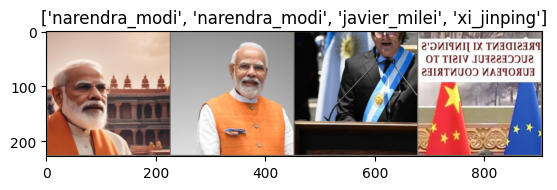

In [9]:
inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

In [10]:
model_conv, criterion, optimizer_conv, exp_lr_scheduler = initialize_model(device, num_classes=len(class_names))

In [11]:
model_ft = train_model(model_conv, criterion, optimizer_conv,
                       exp_lr_scheduler, dataloaders,
                       dataset_sizes, device, num_epochs=50)

Epoch 0/49
----------
train Loss: 2.3288 Acc: 0.2082
val Loss: 2.1980 Acc: 0.2857

Epoch 1/49
----------
train Loss: 2.0745 Acc: 0.3265
val Loss: 1.5764 Acc: 0.4643

Epoch 2/49
----------
train Loss: 1.8120 Acc: 0.4449
val Loss: 1.3726 Acc: 0.5536

Epoch 3/49
----------
train Loss: 1.6160 Acc: 0.4571
val Loss: 1.1697 Acc: 0.6071

Epoch 4/49
----------
train Loss: 1.5285 Acc: 0.4490
val Loss: 1.1016 Acc: 0.6786

Epoch 5/49
----------
train Loss: 1.4400 Acc: 0.4939
val Loss: 1.0534 Acc: 0.6071

Epoch 6/49
----------
train Loss: 1.3392 Acc: 0.5265
val Loss: 1.0900 Acc: 0.6250

Epoch 7/49
----------
train Loss: 1.1777 Acc: 0.5959
val Loss: 0.9436 Acc: 0.6964

Epoch 8/49
----------
train Loss: 1.1744 Acc: 0.6327
val Loss: 0.9077 Acc: 0.6964

Epoch 9/49
----------
train Loss: 1.1488 Acc: 0.6449
val Loss: 0.9317 Acc: 0.7321

Epoch 10/49
----------
train Loss: 1.0824 Acc: 0.6816
val Loss: 0.9036 Acc: 0.7321

Epoch 11/49
----------
train Loss: 1.1436 Acc: 0.6694
val Loss: 0.9127 Acc: 0.7321

Ep

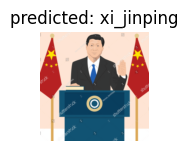

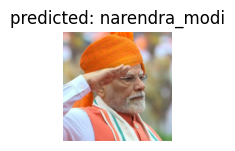

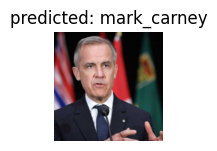

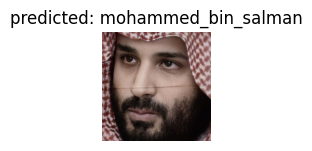

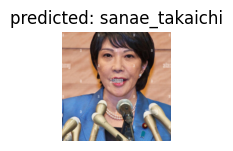

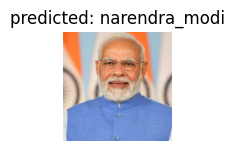

In [12]:
visualize_model(model_conv, dataloaders, class_names, device)
plt.ioff()
plt.show()

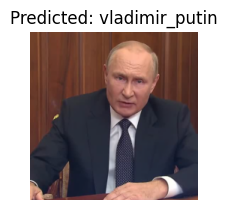

In [13]:
visualize_model_predictions(
    model_conv, data_transformers, class_names, device,
    img_path='../data/politicians/val/vladimir_putin/000070.jpg'
)
plt.ioff()
plt.show()

## 3. Сжатие модели

Сравниваем 4 варианта: FP32, FP16, статическая INT8-квантизация и QAT.

In [14]:
quant_base = load_trained_weights(model_conv, num_classes=len(class_names), device=device)

In [15]:
model_fp16 = to_fp16(quant_base)

In [16]:
model_int8 = static_quantize(quant_base, dataloaders['train'])

/home/dragon/.venvs/libraries/lib/python3.14/site-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  super().__init__(


In [19]:
qat_model = prepare_qat_model(quant_base)
qat_model = train_model(qat_model, criterion, optimizer_conv,
                        exp_lr_scheduler, dataloaders,
                        dataset_sizes, 'cpu', num_epochs=10)
model_qat = convert_qat_model(qat_model)

Epoch 0/9
----------
train Loss: 1.0369 Acc: 0.7306
val Loss: 0.9497 Acc: 0.7679

Epoch 1/9
----------
train Loss: 1.1275 Acc: 0.6776
val Loss: 0.9877 Acc: 0.6607

Epoch 2/9
----------
train Loss: 1.0582 Acc: 0.6857
val Loss: 0.9562 Acc: 0.6964

Epoch 3/9
----------
train Loss: 1.1141 Acc: 0.6612
val Loss: 0.9690 Acc: 0.7143

Epoch 4/9
----------
train Loss: 1.0793 Acc: 0.6816
val Loss: 0.9701 Acc: 0.7321

Epoch 5/9
----------
train Loss: 1.1127 Acc: 0.6939
val Loss: 0.9320 Acc: 0.7143

Epoch 6/9
----------
train Loss: 1.0811 Acc: 0.6735
val Loss: 0.9858 Acc: 0.6964

Epoch 7/9
----------
train Loss: 1.0935 Acc: 0.6612
val Loss: 0.9576 Acc: 0.6964

Epoch 8/9
----------
train Loss: 1.1229 Acc: 0.6490
val Loss: 0.9417 Acc: 0.6964

Epoch 9/9
----------
train Loss: 1.1452 Acc: 0.6449
val Loss: 0.9204 Acc: 0.7500

Training complete in 3m 7s
Best val Acc: 0.767857


## 4. Бенчмарк: размер, скорость, точность

In [20]:
results = benchmark_all(
    {'FP32': quant_base, 'FP16': model_fp16,
     'INT8_static': model_int8, 'QAT': model_qat},
    dataloaders['val'], device=device,
    input_dtypes={'FP16': torch.float16},
)

FP32: size=42.73 МБ, latency=1.72 мс/img, acc=0.7857
FP16: size=21.38 МБ, latency=2.11 мс/img, acc=0.7857
INT8_static: size=10.79 МБ, latency=3.90 мс/img, acc=0.7321
QAT: size=10.79 МБ, latency=3.71 мс/img, acc=0.7500


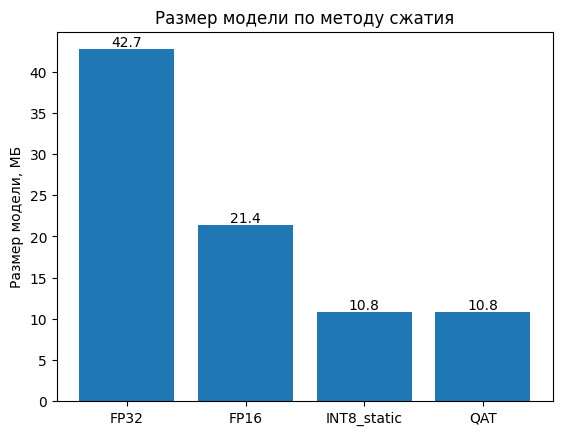

In [21]:
plot_size_vs_method(results)
plt.show()

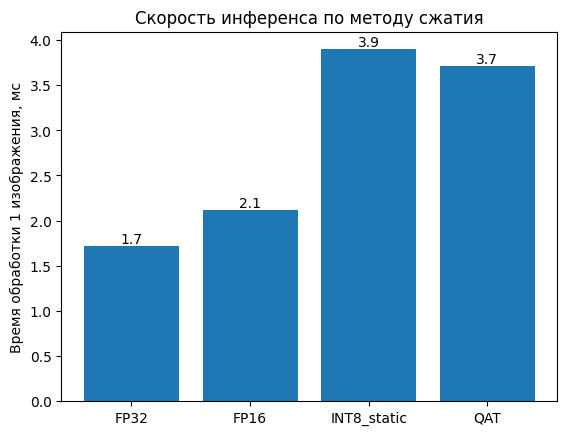

In [22]:
plot_latency_vs_method(results)
plt.show()

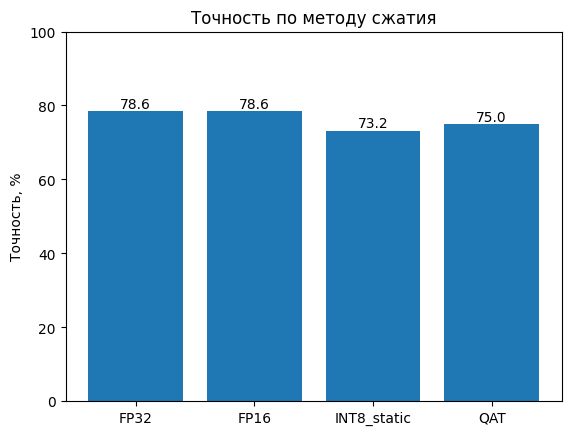

In [23]:
plot_accuracy_vs_method(results)
plt.show()

## 5. Кривая обучения

In [24]:
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
accuracies = []

for frac in fractions:
    _, dl, ds, cls, dev = predprocessing_data(subset_fraction=frac)
    m, c, o, s = initialize_model(dev, num_classes=len(cls))
    m = train_model(m, c, o, s, dl, ds, dev, num_epochs=5)
    accuracies.append(evaluate_accuracy(m, dl['val'], dev))
    print(f'fraction={frac}: accuracy={accuracies[-1]:.4f}')

Using cuda device
Epoch 0/4
----------
train Loss: 2.5212 Acc: 0.0417
val Loss: 2.3281 Acc: 0.0714

Epoch 1/4
----------
train Loss: 2.2147 Acc: 0.1250
val Loss: 2.4748 Acc: 0.0893

Epoch 2/4
----------
train Loss: 2.0578 Acc: 0.2500
val Loss: 2.5892 Acc: 0.1786

Epoch 3/4
----------
train Loss: 2.2021 Acc: 0.1667
val Loss: 2.2670 Acc: 0.2143

Epoch 4/4
----------
train Loss: 2.0024 Acc: 0.2083
val Loss: 2.1469 Acc: 0.1786

Training complete in 0m 21s
Best val Acc: 0.214286
fraction=0.1: accuracy=0.2143
Using cuda device
Epoch 0/4
----------
train Loss: 2.5001 Acc: 0.0820
val Loss: 2.3517 Acc: 0.1786

Epoch 1/4
----------
train Loss: 2.3311 Acc: 0.1803
val Loss: 2.0550 Acc: 0.2321

Epoch 2/4
----------
train Loss: 2.1776 Acc: 0.2459
val Loss: 1.9241 Acc: 0.2143

Epoch 3/4
----------
train Loss: 1.9970 Acc: 0.2951
val Loss: 1.8189 Acc: 0.4464

Epoch 4/4
----------
train Loss: 1.9156 Acc: 0.3770
val Loss: 1.8653 Acc: 0.4643

Training complete in 0m 24s
Best val Acc: 0.464286
fraction=0.2

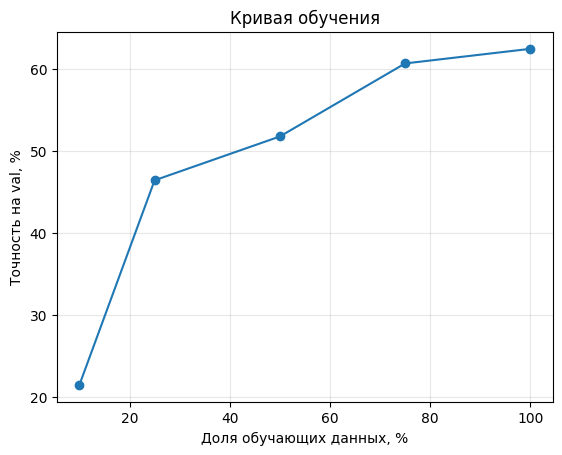

In [25]:
plot_learning_curve(fractions, accuracies)
plt.show()